58900480/58889256 [==============================] - 0s 0us/step
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
vgg16 (Functional)           (None, 4, 4, 512)         14714688  
_________________________________________________________________
flatten (Flatten)            (None, 8192)              0         
_________________________________________________________________
dropout (Dropout)            (None, 8192)              0         
_________________________________________________________________
dense (Dense)                (None, 128)               1048704   
_________________________________________________________________
dropout_1 (Dropout)          (None, 128)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 4)                 516       
Total params: 15,763,908
Trainable params: 8,128,644
Non-

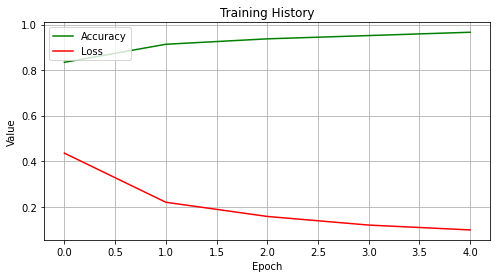

66it [00:18,  3.65it/s]                        

              precision    recall  f1-score   support

      glioma       0.96      0.93      0.94       300
  meningioma       0.93      0.85      0.89       306
     notumor       0.98      1.00      0.99       405
   pituitary       0.89      0.99      0.94       300

    accuracy                           0.95      1311
   macro avg       0.94      0.94      0.94      1311
weighted avg       0.95      0.95      0.94      1311



In [1]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image, ImageEnhance
from sklearn.utils import shuffle
from sklearn.metrics import classification_report
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model

# =======================
# Config
# =======================
IMAGE_SIZE = 128
train_dir = '/kaggle/input/brain-tumor-mri-dataset/Training/'
test_dir = '/kaggle/input/brain-tumor-mri-dataset/Testing/'
unique_labels = sorted(os.listdir(train_dir))

# =======================
# Encode / Decode Labels
# =======================
def encode_label(labels):
    return np.array([unique_labels.index(x) for x in labels])

def decode_label(indices):
    return np.array([unique_labels[x] for x in indices])

# =======================
# Data Augmentation
# =======================
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
    return np.array(image) / 255.0

def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

# =======================
# Data Generator
# =======================
def datagen(paths, labels, batch_size=16, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i+batch_size]
            batch_images = open_images(batch_paths)
            batch_labels = encode_label(labels[i:i+batch_size])
            yield batch_images, batch_labels

# =======================
# Load & Shuffle Data
# =======================
def load_data(path):
    paths, labels = [], []
    for label in os.listdir(path):
        for img_file in os.listdir(os.path.join(path, label)):
            paths.append(os.path.join(path, label, img_file))
            labels.append(label)
    return shuffle(paths, labels)

train_paths, train_labels = load_data(train_dir)
test_paths, test_labels = load_data(test_dir)

# =======================
# Build Model
# =======================
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# Freeze all layers first
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze last 3 conv layers
for layer in base_model.layers[-4:]:
    layer.trainable = True

model = Sequential([
    Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    base_model,
    Flatten(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(len(unique_labels), activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

model.summary()

# =======================
# Train Model
# =======================
batch_size = 20
steps = len(train_paths) // batch_size
epochs = 5

history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps)

# =======================
# Plot Training History
# =======================
plt.figure(figsize=(8, 4))
plt.plot(history.history['sparse_categorical_accuracy'], 'g', label='Accuracy')
plt.plot(history.history['loss'], 'r', label='Loss')
plt.title('Training History')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

# =======================
# Evaluation on Test Set
# =======================
y_pred, y_true = [], []
steps_test = len(test_paths) // batch_size

for x_batch, y_batch in tqdm(datagen(test_paths, test_labels, batch_size=batch_size, epochs=1), total=steps_test):
    preds = model.predict(x_batch)
    pred_classes = np.argmax(preds, axis=1)
    y_pred.extend(decode_label(pred_classes))
    y_true.extend(decode_label(y_batch))

# =======================
# Classification Report
# =======================
print(classification_report(y_true, y_pred))
